# V3 moneyness performance — 1-day monthly study

**This notebook is the computational source of truth.** The matching PDF is written from the same payload.

This report classifies the **same** option contracts as `V3_1d_hourly_empirical_study` into DOTM / OTM / ATM / ITM / DITM. It does not change filters, calibration, contracts, LSM settings, or the market benchmark.

| Item | Setting |
|------|---------|
| Models | GBM, GARCH, Heston, Merton, GARCH–Merton, Heston–Merton |
| Companies | SPY, AAPL, MSFT (pooled in both analyses) |
| Regimes | Crisis, Normal, Late-cycle, COVID (pooled in Analysis 1; separate in Analysis 2) |
| Contracts | Monday nearest-ATM listed calls from the main study (`n = 216` per model) |
| Moneyness | `m = S/K` (calls) |
| Primary metric | RMSE% |
| Secondary | MAE, Bias $, **Bias%**, Early-exercise fraction |


## 0. Methodology

### Same design as the main study
1-day lookback, monthly recalibration, V3 filters (no-arbitrage, DTE 7–60, |S/K−1|≤10%, liquidity), Euler-corrected Heston, option-implied Heston NLS, LSM with 2,000 paths and seed 42. No look-ahead.

### Moneyness rule (calls)
Let `m = S/K`.

| Bucket | Rule |
|--------|------|
| DOTM | m < 0.98 |
| OTM | 0.98 ≤ m < 0.995 |
| ATM | 0.995 ≤ m ≤ 1.005 |
| ITM | 1.005 < m ≤ 1.02 |
| DITM | m > 1.02 |

These five bins partition the main-study 10% moneyness filter. The Monday ATM sampler concentrates mass in ATM.

### Metrics
- RMSE% = 100 × √ mean(((model − market)/market)²)
- Bias $ = mean(model − market)
- Bias% = 100 × mean((model − market)/market)
- BEST = lowest RMSE% among models with n > 0


In [1]:
import sys
from pathlib import Path
from IPython.display import display, HTML
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    scripts = cand / 'V3-Models_result' / 'scripts'
    if scripts.exists():
        sys.path.insert(0, str(scripts))
        break
import run_v3_1d_hourly_moneyness_study as mx
panel = mx.load_panel()
payload = mx.build_payload(panel)
pdf = mx.write_pdf(payload)
print('n_overall', payload['n_overall'])
print('PDF', pdf)

## 1. Shared sample counts


In [1]:
display(HTML('counts'))

Regime,DOTM,OTM,ATM,ITM,DITM,Total
2022-10-21,0,0,1,5,12,18
2022-11-18,13,5,0,0,0,18
2022-12-16,6,1,3,3,5,18
2023-01-20,12,0,0,1,5,18
2023-02-17,12,6,0,0,0,18
2023-03-17,2,8,7,1,0,18
2023-04-21,5,9,4,0,0,18
2023-05-19,18,0,0,0,0,18
2023-06-16,18,0,0,0,0,18
2023-07-21,18,0,0,0,0,18


## 2. Analysis 1 — Overall moneyness


### Table M1. DOTM  ·  m < 0.98  ·  n = 140  ·  **BEST = Heston**


In [1]:
tab = payload['analysis1']['DOTM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,140,99.93,6.7920,-6.7920,-99.93,0.2%,
GARCH,140,99.93,6.7918,-6.7918,-99.93,0.2%,
Heston,140,99.72,6.7777,-6.7777,-99.71,0.5%,BEST
Merton,140,99.93,6.7920,-6.7920,-99.93,0.2%,
GARCH–Merton,140,99.92,6.7911,-6.7911,-99.92,0.3%,
Heston–Merton,140,99.73,6.7785,-6.7785,-99.72,0.5%,


### Table M2. OTM  ·  0.98 ≤ m < 0.995  ·  n = 29  ·  **BEST = Heston–Merton**


In [1]:
tab = payload['analysis1']['OTM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,29,97.46,6.6450,-6.6450,-97.41,7.4%,
GARCH,29,97.69,6.6613,-6.6613,-97.62,5.9%,
Heston,29,94.78,6.4819,-6.4819,-94.58,11.1%,
Merton,29,97.43,6.6436,-6.6436,-97.38,7.8%,
GARCH–Merton,29,97.40,6.6423,-6.6423,-97.32,6.7%,
Heston–Merton,29,94.63,6.4714,-6.4714,-94.41,10.3%,BEST


### Table M3. ATM  ·  0.995 ≤ m ≤ 1.005  ·  n = 15  ·  **BEST = Heston–Merton**


In [1]:
tab = payload['analysis1']['ATM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,15,87.74,5.5528,-5.5528,-87.43,30.8%,
GARCH,15,88.07,5.5814,-5.5814,-87.66,29.9%,
Heston,15,83.40,5.2667,-5.2667,-82.78,34.5%,
Merton,15,87.81,5.5584,-5.5584,-87.50,31.9%,
GARCH–Merton,15,87.28,5.5230,-5.5230,-86.85,30.6%,
Heston–Merton,15,83.35,5.2589,-5.2589,-82.71,32.6%,BEST


### Table M4. ITM  ·  1.005 < m ≤ 1.02  ·  n = 10  ·  **BEST = Heston**


In [1]:
tab = payload['analysis1']['ITM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,10,66.15,4.5714,-4.5714,-64.47,64.9%,
GARCH,10,66.45,4.6035,-4.6035,-64.84,66.9%,
Heston,10,62.06,4.3125,-4.3125,-60.05,61.0%,BEST
Merton,10,66.26,4.5791,-4.5791,-64.60,66.6%,
GARCH–Merton,10,65.24,4.5263,-4.5263,-63.63,65.5%,
Heston–Merton,10,62.44,4.3385,-4.3385,-60.41,60.1%,


### Table M5. DITM  ·  m > 1.02  ·  n = 22  ·  **BEST = GARCH–Merton**


In [1]:
tab = payload['analysis1']['DITM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Mark
GBM,22,33.21,3.1364,-3.1364,-28.86,91.7%,
GARCH,22,33.31,3.1521,-3.1521,-29.03,94.6%,
Heston,22,32.95,3.1073,-3.1073,-28.24,86.1%,
Merton,22,33.15,3.1291,-3.1291,-28.76,92.8%,
GARCH–Merton,22,32.77,3.0972,-3.0972,-28.54,92.2%,BEST
Heston–Merton,22,32.94,3.1016,-3.1016,-28.18,87.8%,


### Figure M1 — Model × Moneyness RMSE% heatmap


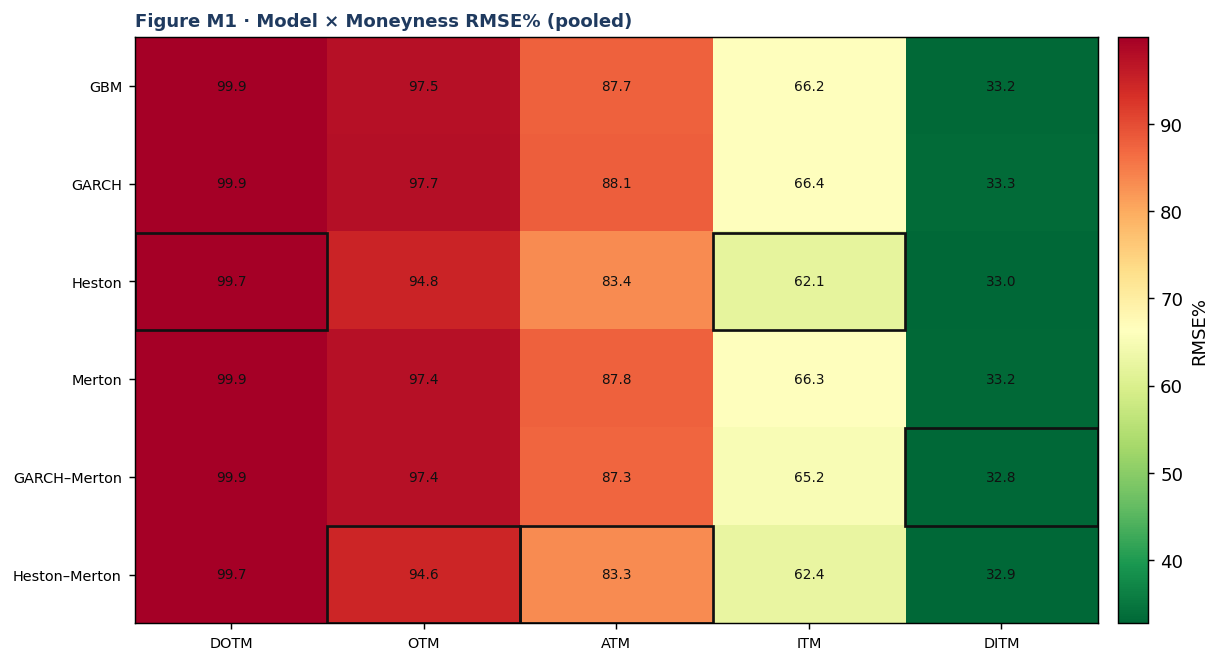

In [1]:
pass

## 3. Analysis 2 — Regime × moneyness


### Figure M2 — RMSE% heatmaps by regime


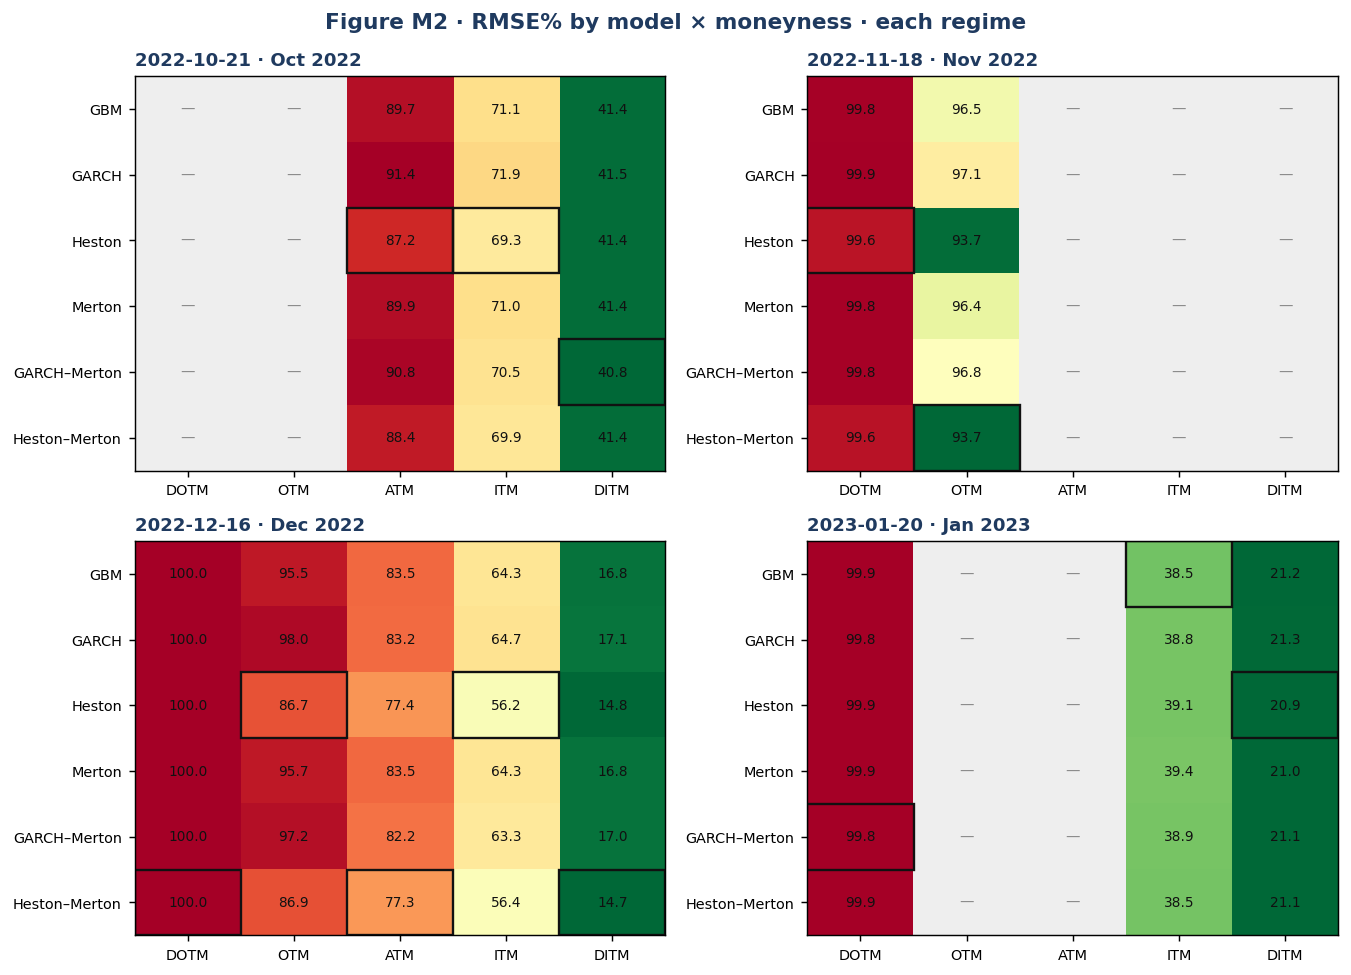

In [1]:
pass

### Table M6 — Best model by regime × moneyness


In [1]:
display(HTML('m6'))

Regime,DOTM,OTM,ATM,ITM,DITM
2022-10-21,—,—,Heston,Heston,GARCH–Merton
2022-11-18,Heston,Heston–Merton,—,—,—
2022-12-16,Heston–Merton,Heston,Heston–Merton,Heston,Heston–Merton
2023-01-20,GARCH–Merton,—,—,GBM,Heston
2023-02-17,Heston,Heston–Merton,—,—,—
2023-03-17,Heston,Heston–Merton,Heston–Merton,Heston,—
2023-04-21,GBM,Heston–Merton,Heston–Merton,—,—
2023-05-19,GARCH–Merton,—,—,—,—
2023-06-16,Heston–Merton,—,—,—,—
2023-07-21,GARCH–Merton,—,—,—,—


### Table M7 — n by regime × moneyness


In [1]:
display(HTML('m7'))

Regime,DOTM,OTM,ATM,ITM,DITM
2022-10-21,0,0,1,5,12
2022-11-18,13,5,0,0,0
2022-12-16,6,1,3,3,5
2023-01-20,12,0,0,1,5
2023-02-17,12,6,0,0,0
2023-03-17,2,8,7,1,0
2023-04-21,5,9,4,0,0
2023-05-19,18,0,0,0,0
2023-06-16,18,0,0,0,0
2023-07-21,18,0,0,0,0


## 4. Findings

- DOTM (n = 140): BEST = Heston with RMSE% = 99.72, Bias% = -99.71.

- OTM (n = 29): BEST = Heston–Merton with RMSE% = 94.63, Bias% = -94.41.

- ATM (n = 15): BEST = Heston–Merton with RMSE% = 83.35, Bias% = -82.71.

- ITM (n = 10): BEST = Heston with RMSE% = 62.06, Bias% = -60.05.

- DITM (n = 22): BEST = GARCH–Merton with RMSE% = 32.77, Bias% = -28.54.

- Overall, the ranking does change with moneyness: DOTM → Heston, OTM → Heston–Merton, ATM → Heston–Merton, ITM → Heston, DITM → GARCH–Merton.

- Inside regimes, the BEST model also changes with moneyness in: 2022-10-21, 2022-11-18, 2022-12-16, 2023-01-20, 2023-02-17, 2023-03-17, 2023-04-21.

- These comparisons use the hourly nearest-ATM sample (09:59–15:59; LSM skipped at Friday 15:59). ATM still holds most of the mass; sparse DOTM/DITM buckets should be read as descriptive.


## 5. Re-run

```python
import run_v3_1d_hourly_moneyness_study as mx
payload = mx.run()
```

Requires the main study contract CSVs under `V3-Models_result/results/empirical_study_1d_hourly/contracts/`.
